# **Feature Engineering Notebook**
In this notebook, I will be doing feature engineering and introduce new features as required to help my model train better.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from os import path
path_train = '/content/drive/MyDrive/Colab_Notebooks/predictive_maintenance_engine/data/raw/train_FD001.txt'
path_test = '/content/drive/MyDrive/Colab_Notebooks/predictive_maintenance_engine/data/raw/test_FD001.txt'
path_rul = '/content/drive/MyDrive/Colab_Notebooks/predictive_maintenance_engine/data/raw/RUL_FD001.txt'

In [4]:
columns = ['engine_id', 'cycle']
columns += [f'operational_setting_{i}' for i in range(1,4)]
columns += [f'sensors_{i}' for i in range(1,22)]

In [5]:
train_df_fd001 = pd.read_csv(path_train, sep = '\s+', header = None, names = columns)
test_df_fd001 = pd.read_csv(path_test, sep = '\s+', header = None, names = columns)
RUL_df_fd001 = pd.read_csv(path_rul, sep = '\s+', header = None, names = ['RUL'])

In [6]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
test_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [8]:
RUL_df_fd001.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [9]:
engine_lifetime = train_df_fd001.groupby('engine_id')['cycle'].max()

In [10]:
# Vectorization concept
train_df_fd001['RUL'] = train_df_fd001['engine_id'].map(engine_lifetime) - train_df_fd001['cycle']
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [11]:
# Piecewise RUL
train_df_fd001['RUL'] = train_df_fd001['RUL'].clip(upper=125)
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [12]:
# From previous EDA notebook
useful_sensors = ['sensors_2','sensors_3','sensors_4','sensors_7','sensors_8','sensors_9',
                  'sensors_11','sensors_12','sensors_13','sensors_14','sensors_15',
                  'sensors_17','sensors_20','sensors_21']

dropped_sensors = ['sensors_1','sensors_5','sensors_6','sensors_10','sensors_16',
                   'sensors_18','sensors_19']

op_settings = ['operational_setting_1','operational_setting_2','operational_setting_3']

# **Rolling Statistics**

In [13]:
eng1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()
eng1['s7_rmean_10'] = eng1['sensors_7'].rolling(window = 10, min_periods = 1).mean()
eng1['s7_rstd_10'] = eng1['sensors_7'].rolling(window = 10, min_periods = 1).std()

eng1[['cycle', 'sensors_7', 's7_rmean_10', 's7_rstd_10']].head(12)

,cycle,sensors_7,s7_rmean_10,s7_rstd_10
0,1,554.36,554.360000,NaN
1,2,553.75,554.055000,0.431335
2,3,554.26,554.123333,0.327159
3,4,554.45,554.205000,0.313103
4,5,554.00,554.164000,0.286234
5,6,554.67,554.248333,0.328963
6,7,554.34,554.261429,0.302293
7,8,553.85,554.210000,0.315414
8,9,553.69,554.152222,0.342191
9,10,553.59,554.096000,0.368366


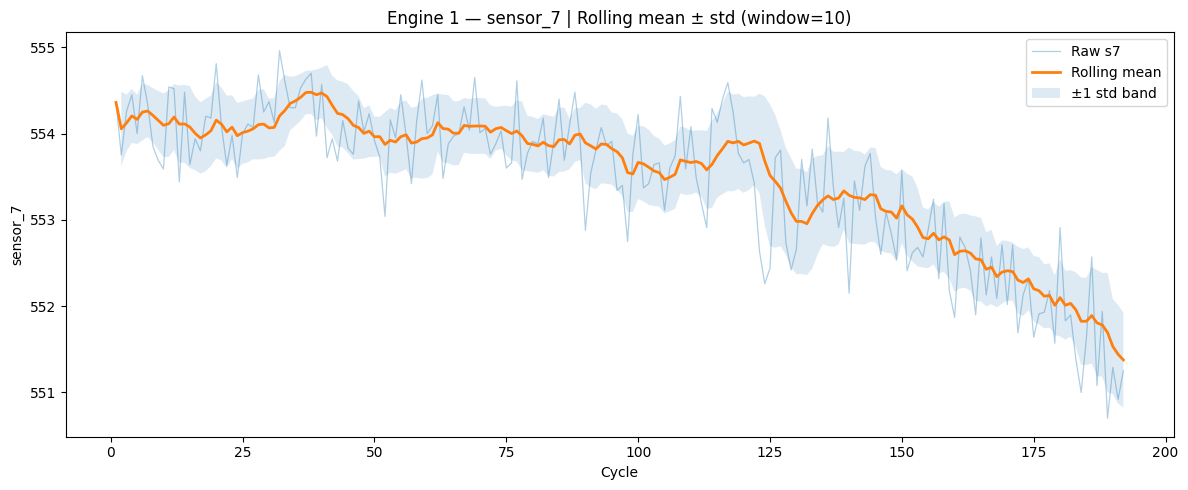

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(eng1['cycle'], eng1['sensors_7'], alpha=0.35, linewidth=0.9, label='Raw s7')
ax1.plot(eng1['cycle'], eng1['s7_rmean_10'], linewidth=2, label='Rolling mean')
ax1.fill_between(eng1['cycle'],
                 eng1['s7_rmean_10'] - eng1['s7_rstd_10'],
                 eng1['s7_rmean_10'] + eng1['s7_rstd_10'],
                 alpha=0.15, label='±1 std band')

ax1.set_xlabel('Cycle')
ax1.set_ylabel('sensor_7')
ax1.set_title('Engine 1 — sensor_7 | Rolling mean ± std (window=10)')
ax1.legend()
plt.tight_layout()
plt.show()

**From above plot, we can see that the thick orange line(rolling mean) shows downward trend as the cycle of the engine goes on increasing. Also, we can see that there's a sharp decline in the sensor 7 reading around 120 cycles and it declines rapidly compare to the first half where the engine is healthy. Finally, the std band width is almost consistent over the entire cycles which tells that there's no variability on sensor 7 and here mean is the major factor to observe the degrading trend.**

In [15]:
# Now, I am going to apply rolling feature to all the sensors of all engines at once after testing
# that thing with just one sensor-7 above.

def rolling_feature(df):
  window_sizes = [5, 10, 20, 30]      # I am going to try for multiple window cycles to get a clear picture of the sensors
  for sensor in useful_sensors:
    for size in window_sizes:
      df[f'{sensor}_rmean_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).mean())
      df[f'{sensor}_rstd_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).std())
      df[f'{sensor}_rmin_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).min())
      df[f'{sensor}_rmax_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).max())

  return df

train_df_fd001 = rolling_feature(train_df_fd001)

In [16]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_21_rmin_10,sensors_21_rmax_10,sensors_21_rmean_20,sensors_21_rstd_20,sensors_21_rmin_20,sensors_21_rmax_20,sensors_21_rmean_30,sensors_21_rstd_30,sensors_21_rmin_30,sensors_21_rmax_30
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,23.4190,23.4190,23.419000,NaN,23.4190,23.4190,23.419000,NaN,23.4190,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,23.4190,23.4236,23.421300,0.003253,23.4190,23.4236,23.421300,0.003253,23.4190,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,23.3442,23.4236,23.395600,0.044573,23.3442,23.4236,23.395600,0.044573,23.3442,23.4236
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,23.3442,23.4236,23.390175,0.037977,23.3442,23.4236,23.390175,0.037977,23.3442,23.4236
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,23.3442,23.4236,23.393020,0.033498,23.3442,23.4236,23.393020,0.033498,23.3442,23.4236


# **Rolling Slope**

In [17]:
useful_sensors

['sensors_2',
 'sensors_3',
 'sensors_4',
 'sensors_7',
 'sensors_8',
 'sensors_9',
 'sensors_11',
 'sensors_12',
 'sensors_13',
 'sensors_14',
 'sensors_15',
 'sensors_17',
 'sensors_20',
 'sensors_21']

In [18]:
def calc_slope(y):
  x = np.arange(len(y))       # gives the positions in x-axis like [0,1,2,3,4.......,y-1]
  if len(y) < 2:
    return np.nan
  return np.polyfit(x, y, 1)[0]       # draws line at the points(obtained from x and y(sensor values) and then returns slope)

def rolling_slope(df):
  for sensor in useful_sensors:
    for size in [10, 20]:
      df[f'{sensor}_rslope_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 2).apply(calc_slope, raw = True))
  return df

train_df_fd001 = rolling_slope(train_df_fd001)

# I have use min_periods = 2 here because we need atleast 2 points to fit a line.
# raw = True will pass the window values as numpy array instead of series to calc_slope which makes np.polyfit work correctly and runs faster
# It only passes those values as array but later transform again convert them back into series and returns original dataframe.

In [19]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_14_rslope_10,sensors_14_rslope_20,sensors_15_rslope_10,sensors_15_rslope_20,sensors_17_rslope_10,sensors_17_rslope_20,sensors_20_rslope_10,sensors_20_rslope_20,sensors_21_rslope_10,sensors_21_rslope_20
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,-7.130,-7.130,0.01230,0.01230,-8.637964e-14,-8.637964e-14,-0.060,-0.060,0.00460,0.00460
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,-2.695,-2.695,-0.00085,-0.00085,-1.000000e+00,-1.000000e+00,-0.055,-0.055,-0.03740,-0.03740
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,-1.263,-1.263,-0.01679,-0.01679,-2.000000e-01,-2.000000e-01,-0.059,-0.059,-0.02147,-0.02147
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.730,-0.730,-0.00438,-0.00438,2.000000e-01,2.000000e-01,-0.044,-0.044,-0.00789,-0.00789


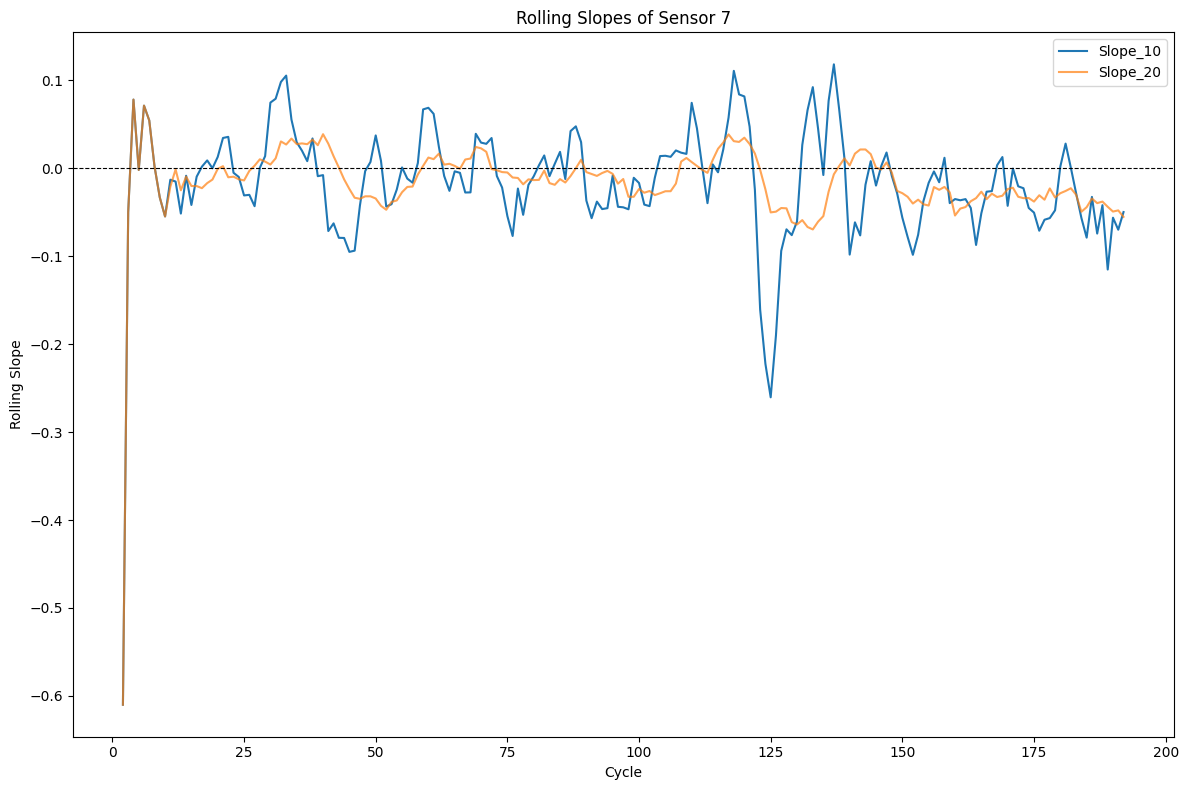

In [20]:
engine_1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()

fig, ax1 = plt.subplots(figsize = (12,8))
ax1.plot(engine_1['cycle'], engine_1['sensors_7_rslope_10'], linewidth = 1.5, label = 'Slope_10')
ax1.plot(engine_1['cycle'], engine_1['sensors_7_rslope_20'], linewidth = 1.5, label = 'Slope_20', alpha = 0.7)
ax1.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax1.set_xlabel('Cycle')
ax1.set_ylabel("Rolling Slope")
ax1.set_title('Rolling Slopes of Sensor 7', fontsize = 12)
ax1.legend()

plt.tight_layout()
plt.show()

**From the above plot, we see that the sensor 7 fluctuates near '0' with slight +0.1 to -0.1 change from (5 to 120) cycles which tells us that reading is consistent when the engine is healthy. But later after around 120 cycle, it rapidly drops down and keeps on dropping negatively below '0' which shows sensor 7 declines when engine is near its failure.**

**From (0 to 5 cycles we see a sharp negative line coming upto -0.6, that's due to NaN values at the starting phase and here's that doesn't matter and we can ignore that.**

# **EWMA**

In [21]:
def ewma(df):
  for sensor in useful_sensors:
    df[f'{sensor}_ewm'] = df.groupby('engine_id')[sensor].transform(lambda x:x.ewm(span = 10).mean())

  return df

train_df_fd001 = ewma(train_df_fd001)

In [22]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_8_ewm,sensors_9_ewm,sensors_11_ewm,sensors_12_ewm,sensors_13_ewm,sensors_14_ewm,sensors_15_ewm,sensors_17_ewm,sensors_20_ewm,sensors_21_ewm
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.060000,9046.190000,47.470000,521.660000,2388.020000,8138.620000,8.419500,392.000000,39.060000,23.419000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.049000,9045.024000,47.481000,522.001000,2388.047500,8134.698500,8.426265,392.000000,39.027000,23.421530
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.061462,9048.206179,47.396179,522.169435,2388.040465,8134.108173,8.422862,391.196013,38.996047,23.390444
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.077453,9048.625847,47.308485,522.396946,2388.053490,8134.016527,8.404853,391.460891,38.957814,23.384993
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.072443,9050.498754,47.300308,522.337537,2388.049617,8133.954368,8.411900,391.902727,38.941217,23.390565


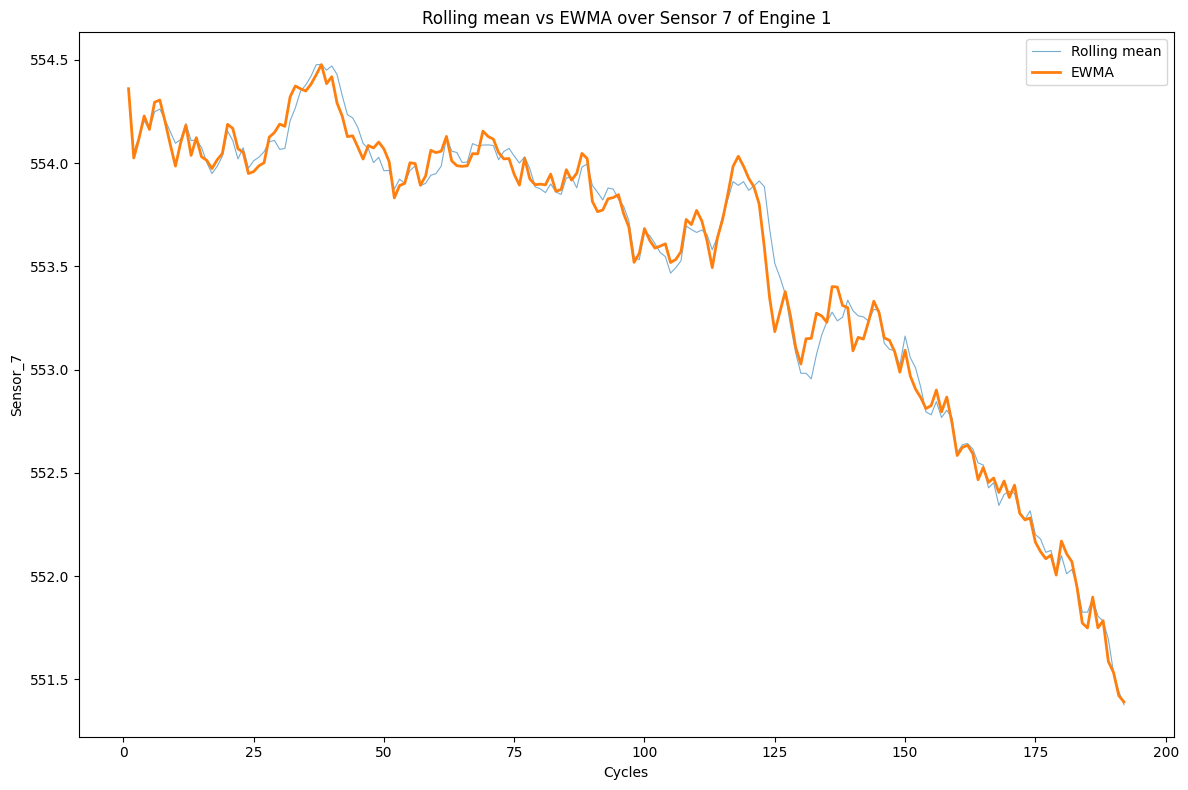

In [23]:
engine_1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()

fig, ax = plt.subplots(figsize = (12, 8))
ax.plot(engine_1['cycle'], engine_1['sensors_7_rmean_10'], linewidth = 0.8, label = 'Rolling mean', alpha = 0.6)
ax.plot(engine_1['cycle'], engine_1['sensors_7_ewm'], linewidth = 2, label = 'EWMA')
ax.set_xlabel('Cycles')
ax.set_ylabel('Sensor_7')
ax.set_title('Rolling mean vs EWMA over Sensor 7 of Engine 1')
ax.legend()
plt.tight_layout()
plt.show()

**EWMA reacts faster to any changes than the rolling mean as we can see that from above plot because EWMA gives more importance to recent things than past. It is important because if an engine suddenly starts degrading faster, EWMA will pick it up before the rolling mean does.**

In [24]:
# I calculated first derivative here to keep on my features

def derivative(df):
  for sensor in useful_sensors:
    df[f'{sensor}_der'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(10, min_periods = 1).mean().diff())

  return df

train_df_fd001 = derivative(train_df_fd001)

In [25]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_8_der,sensors_9_der,sensors_11_der,sensors_12_der,sensors_13_der,sensors_14_der,sensors_15_der,sensors_17_der,sensors_20_der,sensors_21_der
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,-0.0100,-1.060000,0.010,0.310,0.025,-3.565000,0.006150,0.000000,-0.030000,0.002300
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.0100,2.603333,-0.070,0.150,-0.005,-0.608333,-0.002617,-0.666667,-0.026667,-0.025700
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.0125,0.436667,-0.070,0.185,0.010,-0.154167,-0.013708,0.166667,-0.030833,-0.005425
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.0025,1.396000,-0.012,-0.023,-0.002,-0.098500,0.004015,0.300000,-0.014500,0.002845


In [26]:
# Now, I will calculate accelaeration(second derivative)

def acceleration(df):
  for sensor in useful_sensors:
    df[f'{sensor}_acc'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(10, min_periods = 1).mean().diff().diff())

  return df

train_df_fd001 = acceleration(train_df_fd001)

In [27]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_8_acc,sensors_9_acc,sensors_11_acc,sensors_12_acc,sensors_13_acc,sensors_14_acc,sensors_15_acc,sensors_17_acc,sensors_20_acc,sensors_21_acc
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.0200,3.663333,-0.080,-0.160,-0.030,2.956667,-0.008767,-0.666667,0.003333,-0.028000
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.0025,-2.166667,0.000,0.035,0.015,0.454167,-0.011092,0.833333,-0.004167,0.020275
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.0150,0.959333,0.058,-0.208,-0.012,0.055667,0.017723,0.133333,0.016333,0.008270


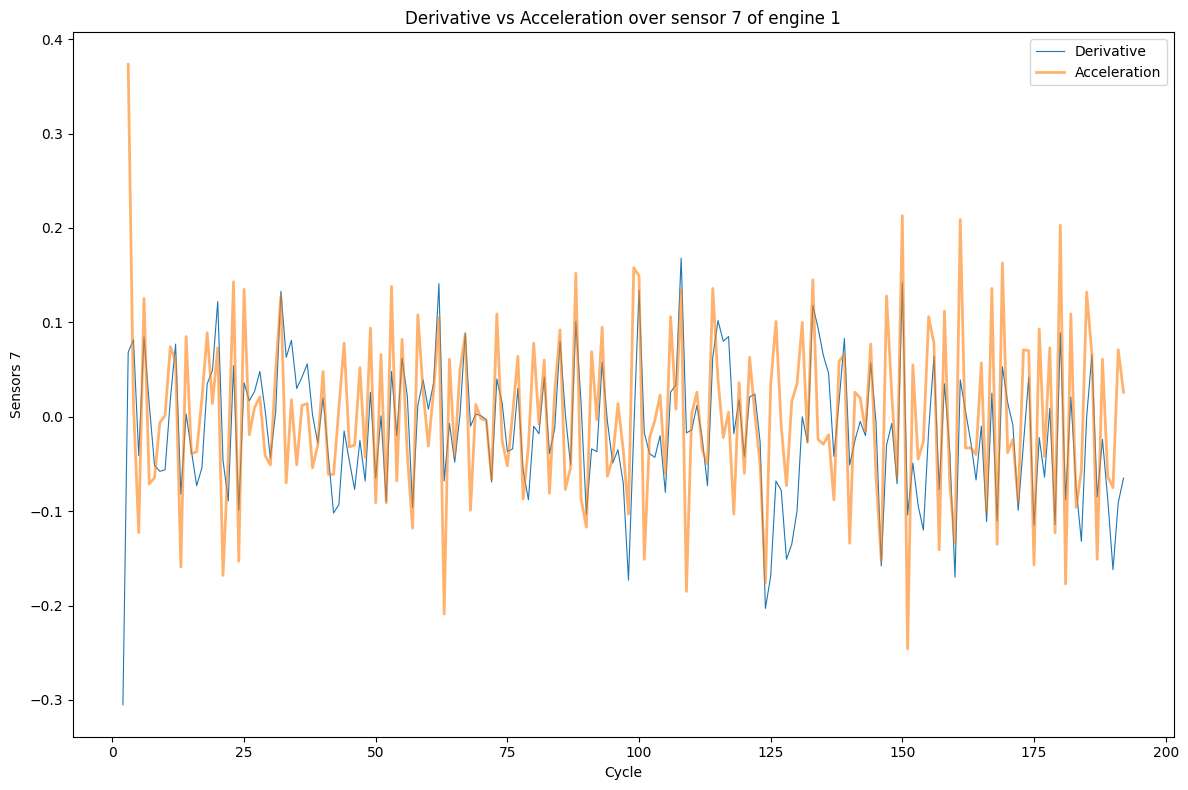

In [28]:
engine1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()
fig, ax = plt.subplots(figsize = (12, 8))
ax.plot(engine1['cycle'], engine1['sensors_7_der'], linewidth = 0.8, label = 'Derivative')
ax.plot(engine1['cycle'], engine1['sensors_7_acc'], linewidth = 2, label = 'Acceleration', alpha = 0.6)
ax.set_xlabel('Cycle')
ax.set_ylabel('Sensors 7')
ax.set_title('Derivative vs Acceleration over sensor 7 of engine 1')
ax.legend()
plt.tight_layout()
plt.show()

# **Cross Sensors Features**
**Here, the idea is that sometimes alone sensors may not give clear information and we may need multiple sensors to do cross sensors features like ratios, difference to get a clear picture of the engine.**

In [29]:
# Sensor ratios

train_df_fd001['ratio_s11_s4'] = train_df_fd001['sensors_11'] / train_df_fd001['sensors_4']
train_df_fd001['ratio_s15_s14'] = train_df_fd001['sensors_15'] / train_df_fd001['sensors_14']
train_df_fd001['ratio_s13_s4'] = train_df_fd001['sensors_13'] / train_df_fd001['sensors_4']

In [30]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12_acc,sensors_13_acc,sensors_14_acc,sensors_15_acc,sensors_17_acc,sensors_20_acc,sensors_21_acc,ratio_s11_s4,ratio_s15_s14,ratio_s13_s4
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033893,0.001035,1.704998
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033846,0.001037,1.701947
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,-0.160,-0.030,2.956667,-0.008767,-0.666667,0.003333,-0.028000,0.033663,0.001035,1.700634
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.035,0.015,0.454167,-0.011092,0.833333,-0.004167,0.020275,0.033619,0.001029,1.703496
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.208,-0.012,0.055667,0.017723,0.133333,0.016333,0.008270,0.033622,0.001036,1.698198


In [31]:
print(train_df_fd001[['sensors_4','sensors_11','ratio_s11_s4','RUL']].corr()['RUL'])
print()
print(train_df_fd001[['sensors_15', 'sensors_14', 'ratio_s15_s14', 'RUL']].corr()['RUL'])
print()
print(train_df_fd001[['sensors_13', 'sensors_4', 'ratio_s13_s4', 'RUL']].corr()['RUL'])

sensors_4      -0.757157
sensors_11     -0.775230
ratio_s11_s4    0.134071
RUL             1.000000
Name: RUL, dtype: float64

sensors_15      -0.720858
sensors_14      -0.369753
ratio_s15_s14   -0.508116
RUL              1.000000
Name: RUL, dtype: float64

sensors_13     -0.624034
sensors_4      -0.757157
ratio_s13_s4    0.755552
RUL             1.000000
Name: RUL, dtype: float64


**I calculated the couple of ratios between sensors and their correlation with RUL. But, what I found is that the individual correlation of sensors are more with RUL than their cross ratios which means the ratois are not adding any extra information to the data, so I can drop them. But, I calculated ratios just to see if there's something extra that I can get but I didn't found them.**

In [32]:
train_df_fd001 = train_df_fd001.drop(columns = ['ratio_s11_s4','ratio_s15_s14','ratio_s13_s4'], axis = 1)

In [33]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_8_acc,sensors_9_acc,sensors_11_acc,sensors_12_acc,sensors_13_acc,sensors_14_acc,sensors_15_acc,sensors_17_acc,sensors_20_acc,sensors_21_acc
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.0200,3.663333,-0.080,-0.160,-0.030,2.956667,-0.008767,-0.666667,0.003333,-0.028000
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.0025,-2.166667,0.000,0.035,0.015,0.454167,-0.011092,0.833333,-0.004167,0.020275
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.0150,0.959333,0.058,-0.208,-0.012,0.055667,0.017723,0.133333,0.016333,0.008270


In [34]:
# Sensor Differences

train_df_fd001['diff_s4_s3'] = train_df_fd001['sensors_4'] - train_df_fd001['sensors_3']
train_df_fd001['diff_s12_s11'] = train_df_fd001['sensors_12'] - train_df_fd001['sensors_11']
train_df_fd001['diff_s15_s14'] = train_df_fd001['sensors_15'] - train_df_fd001['sensors_14']

In [35]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12_acc,sensors_13_acc,sensors_14_acc,sensors_15_acc,sensors_17_acc,sensors_20_acc,sensors_21_acc,diff_s4_s3,diff_s12_s11,diff_s15_s14
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-189.10,474.19,-8130.2005
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-188.68,474.79,-8123.0582
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,-0.160,-0.030,2.956667,-0.008767,-0.666667,0.003333,-0.028000,-183.79,475.15,-8124.8122
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.035,0.015,0.454167,-0.011092,0.833333,-0.004167,0.020275,-180.92,475.73,-8125.4618
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.208,-0.012,0.055667,0.017723,0.133333,0.016333,0.008270,-176.63,474.91,-8125.3706


In [36]:
print(train_df_fd001[['sensors_3','sensors_4','diff_s4_s3','RUL']].corr()['RUL'])
print()
print(train_df_fd001[['sensors_11', 'sensors_12', 'diff_s12_s11','RUL']].corr()['RUL'])
print()
print(train_df_fd001[['sensors_14', 'sensors_15', 'diff_s15_s14','RUL']].corr()['RUL'])

sensors_3    -0.655030
sensors_4    -0.757157
diff_s4_s3   -0.423248
RUL           1.000000
Name: RUL, dtype: float64

sensors_11     -0.775230
sensors_12      0.748870
diff_s12_s11    0.779533
RUL             1.000000
Name: RUL, dtype: float64

sensors_14     -0.369753
sensors_15     -0.720858
diff_s15_s14    0.368475
RUL             1.000000
Name: RUL, dtype: float64


**Again, same goes with the sensor differences features, I calculated them but they are also not adding any new information so I can drop them just like before.**

In [37]:
train_df_fd001 = train_df_fd001.drop(columns = ['diff_s4_s3','diff_s12_s11','diff_s15_s14'], axis = 1)
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_8_acc,sensors_9_acc,sensors_11_acc,sensors_12_acc,sensors_13_acc,sensors_14_acc,sensors_15_acc,sensors_17_acc,sensors_20_acc,sensors_21_acc
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.0200,3.663333,-0.080,-0.160,-0.030,2.956667,-0.008767,-0.666667,0.003333,-0.028000
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.0025,-2.166667,0.000,0.035,0.015,0.454167,-0.011092,0.833333,-0.004167,0.020275
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.0150,0.959333,0.058,-0.208,-0.012,0.055667,0.017723,0.133333,0.016333,0.008270


In [38]:
"""
Cumulative Features - These features capture the history of what has happened to the engine over
its entire observed life not just the recent window.

I am going to calculated some cumulative features and see if I could find any useful information
for my model from them.
"""

def cumulative_features(df):
  for sensor in useful_sensors:
    # Cumulative max deviation - Counts worst single deviation

    baseline = df[df['cycle'] <= 10].groupby('engine_id')[sensor].mean().rename('baseline')
    df = df.merge(baseline, on = 'engine_id', how = 'left')
    df['deviation']  = (df[sensor] - df['baseline']).abs()
    df[f'{sensor}_cummax_dev'] = df.groupby('engine_id')['deviation'].transform('cummax')
    df = df.drop(columns = ['baseline','deviation'])

    # Cumulative stress - counts how many cycles the sensor spent in a danger zone

    healthy = df[df['cycle'] <= 10].groupby('engine_id')[sensor]
    stress_threshold = (healthy.mean() + 2 * healthy.std()).rename('threshold')
    df = df.merge(stress_threshold, on = 'engine_id', how = 'left')
    df['stressed'] = (df[sensor] > df['threshold']).astype(int)
    df[f'{sensor}_cumstress'] = df.groupby('engine_id')['stressed'].transform('cumsum')
    df = df.drop(columns = ['threshold','stressed'])

  return df

train_df_fd001 = cumulative_features(train_df_fd001)

In [39]:
train_df_fd001.tail()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_14_cummax_dev,sensors_14_cumstress,sensors_15_cummax_dev,sensors_15_cumstress,sensors_17_cummax_dev,sensors_17_cumstress,sensors_20_cummax_dev,sensors_20_cumstress,sensors_21_cummax_dev,sensors_21_cumstress
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8.199,4,0.13348,51,5.6,94,0.815,0,0.33917,1
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8.199,4,0.13348,52,5.6,95,0.815,0,0.33917,1
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8.199,4,0.14618,53,5.6,96,0.815,0,0.37937,1
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8.199,4,0.14618,54,5.6,97,0.815,0,0.37937,1
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,8.199,4,0.14618,55,5.6,98,0.815,0,0.37937,1


# **Health Index**
**I am going to calculate the health index (a single number between 0 and 1) of the engines beacause it will help me to compress my 14 dufferent useful sensor values into a single number between 0 and 1, where "1" means the engine is healthy and "0" means it's degraded.**
**So, the early cycles will have HI value near "1" and later on it will go near "0".**

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

healthy_data = train_df_fd001[train_df_fd001['cycle'] <= 10][useful_sensors]

scaler = StandardScaler()
scaler.fit(healthy_data)

scaled_all = scaler.transform(train_df_fd001[useful_sensors])

healthy_data_scaled = scaler.transform(healthy_data)
pca = PCA(n_components = 1)
pca.fit(healthy_data_scaled)

pc1 = pca.transform(scaled_all).flatten()

pc1_min, pc1_max = pc1.min(), pc1.max()
health_index = (pc1 - pc1_min) / (pc1_max - pc1_min)
print(health_index)
health_index = 1 - health_index
print(health_index)

train_df_fd001['health_index'] = health_index

[0.2477687  0.29327916 0.24363036 ... 0.81987829 0.8063502  0.83414822]
[0.7522313  0.70672084 0.75636964 ... 0.18012171 0.1936498  0.16585178]


In [41]:
train_df_fd001.tail()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_14_cumstress,sensors_15_cummax_dev,sensors_15_cumstress,sensors_17_cummax_dev,sensors_17_cumstress,sensors_20_cummax_dev,sensors_20_cumstress,sensors_21_cummax_dev,sensors_21_cumstress,health_index
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,4,0.13348,51,5.6,94,0.815,0,0.33917,1,0.231024
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,4,0.13348,52,5.6,95,0.815,0,0.33917,1,0.219024
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,4,0.14618,53,5.6,96,0.815,0,0.37937,1,0.180122
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,4,0.14618,54,5.6,97,0.815,0,0.37937,1,0.193650
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,4,0.14618,55,5.6,98,0.815,0,0.37937,1,0.165852


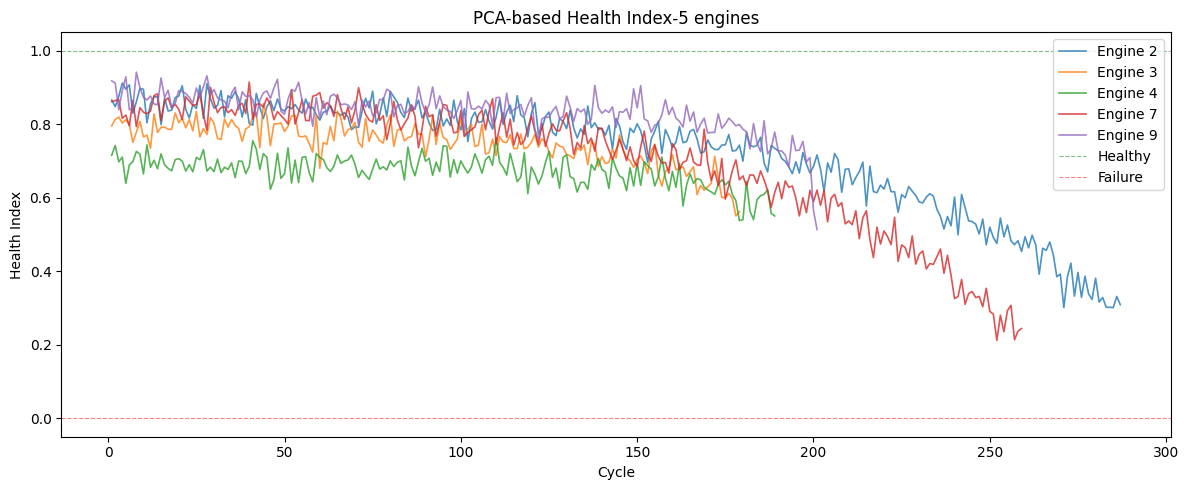

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))

for engine_id in [2, 3, 4, 7, 9]:
    eng = train_df_fd001[train_df_fd001['engine_id'] == engine_id]
    ax.plot(eng['cycle'], eng['health_index'], linewidth=1.2, alpha=0.8, label=f'Engine {engine_id}')

ax.axhline(1.0, color='green', linestyle='--', linewidth=0.8, alpha=0.5, label='Healthy')
ax.axhline(0.0, color='red',   linestyle='--', linewidth=0.8, alpha=0.5, label='Failure')
ax.set_xlabel('Cycle')
ax.set_ylabel('Health Index')
ax.set_title('PCA-based Health Index-5 engines')
ax.legend()
plt.tight_layout()
plt.show()

# **Mahalanobis Distance**
**It is somehow similar to Euclidean distance but it is more smart because it captures multivariate deviation like it doesn't just look at one sensor at a time, but it looks at all sensors simultaneously and asks "is this combination of readings unusual?"**

In [44]:
from scipy.spatial.distance import mahalanobis

healthy_data = train_df_fd001[train_df_fd001['cycle'] <= 10][useful_sensors]
healthy_mean = healthy_data.mean().values
healthy_cov = healthy_data.cov().values
inv_cov = np.linalg.inv(healthy_cov)

train_df_fd001['mahal_dist'] = train_df_fd001[useful_sensors].apply(lambda row:mahalanobis(row.values, healthy_mean, inv_cov), axis = 1)

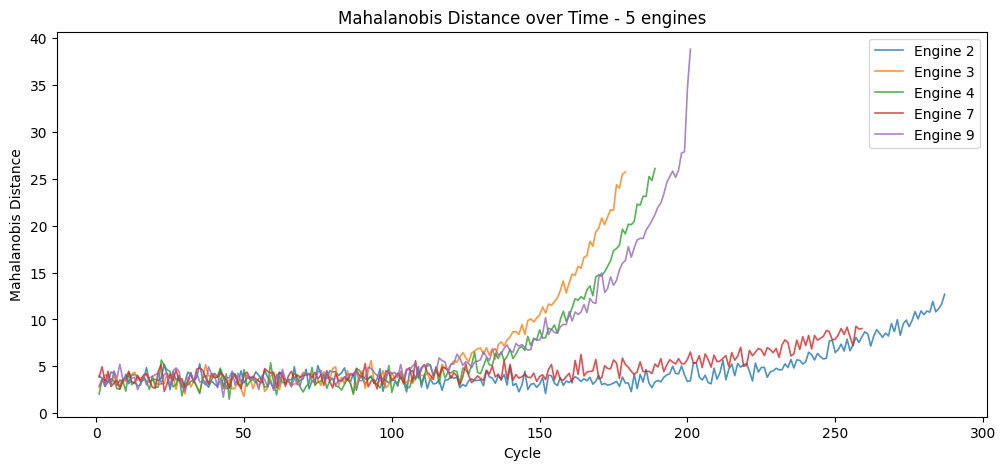

In [55]:
fig, ax = plt.subplots(figsize=(12, 5))

for engine_id in [2, 3, 4, 7, 9]:
    eng = train_df_fd001[train_df_fd001['engine_id'] == engine_id]
    ax.plot(eng['cycle'], eng['mahal_dist'], linewidth=1.2, alpha=0.8, label=f'Engine {engine_id}')

ax.set_xlabel('Cycle')
ax.set_ylabel('Mahalanobis Distance')
ax.set_title('Mahalanobis Distance over Time - 5 engines')
ax.legend()
plt.show()

**From above plot, we can see that the distance is small in early cycles and goes on increasing and becomes large over the time time when the cycle increases.**

In [56]:
train_df_fd001.columns

Index(['engine_id', 'cycle', 'operational_setting_1', 'operational_setting_2',
       'operational_setting_3', 'sensors_1', 'sensors_2', 'sensors_3',
       'sensors_4', 'sensors_5',
       ...
       'sensors_15_cummax_dev', 'sensors_15_cumstress',
       'sensors_17_cummax_dev', 'sensors_17_cumstress',
       'sensors_20_cummax_dev', 'sensors_20_cumstress',
       'sensors_21_cummax_dev', 'sensors_21_cumstress', 'health_index',
       'mahal_dist'],
      dtype='object', length=351)

In [65]:
# Now, I am going to check correlation of all these features that I made with RUL
# so only the top features should go into our model training later.

from scipy.stats import spearmanr

exclude = ['engine_id','cycle','operational_setting_1','operational_setting_2','operational_setting_3','RUL'] + useful_sensors
feature_cols = [col for col in train_df_fd001.columns if col not in exclude]

# Correlation
pearson = train_df_fd001[feature_cols].corrwith(train_df_fd001['RUL'])
spearman = pd.Series([spearmanr(train_df_fd001[col], train_df_fd001['RUL'])[0] for col in feature_cols], index = feature_cols)

corr_table = pd.DataFrame({
    'pearson': pearson,
    'spearman': spearman,
    'abs_pearson': pearson.abs()
}).sort_values('abs_pearson', ascending = False)

print(corr_table.head(20))

                        pearson  spearman  abs_pearson
sensors_11_cummax_dev -0.843582 -0.812996     0.843582
sensors_4_cummax_dev  -0.822760 -0.796786     0.822760
sensors_4_rmean_5     -0.815743 -0.756118     0.815743
sensors_17_ewm        -0.815593 -0.757624     0.815593
sensors_17_rmean_10   -0.815216 -0.757478     0.815216
sensors_4_ewm         -0.814830 -0.754637     0.814830
sensors_15_ewm        -0.814461 -0.752822     0.814461
sensors_15_rmean_10   -0.814061 -0.752394     0.814061
sensors_11_rmean_5    -0.814046 -0.754053     0.814046
sensors_4_rmean_10    -0.814031 -0.753954     0.814031
sensors_3_ewm         -0.811370 -0.750960     0.811370
sensors_3_rmean_10    -0.811018 -0.750699     0.811018
sensors_15_rmean_5    -0.810432 -0.749402     0.810432
sensors_21_ewm         0.809813  0.752583     0.809813
sensors_11_ewm        -0.809457 -0.749594     0.809457
sensors_21_rmean_10    0.809448  0.752285     0.809448
sensors_11_rmean_10   -0.808694 -0.748858     0.808694
sensors_20

In [67]:
# Now, let's check for redundancy because sometimes there may be identical features with
# high correlation but they basically gives the similar information so we can drop one of them
# to reduce redundancy.

feature_corr = train_df_fd001[feature_cols].corr().abs()

# Taking only upper triangle features only to avoid duplicate
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k = 1).astype(bool))
redundant = [(col, row) for col in upper.columns
                        for row in upper.index
                        if upper.loc[row, col] > 0.95]

print(f"\nRedundant pairs (corr > 0.95): {len(redundant)}")
for pair in redundant[:10]:
    print(f"  {pair[0]} and {pair[1]}")


Redundant pairs (corr > 0.95): 1372
  sensors_2_rmean_10 and sensors_2_rmean_5
  sensors_2_rmean_20 and sensors_2_rmean_5
  sensors_2_rmean_20 and sensors_2_rmean_10
  sensors_2_rmax_20 and sensors_2_rmax_10
  sensors_2_rmean_30 and sensors_2_rmean_10
  sensors_2_rmean_30 and sensors_2_rmean_20
  sensors_2_rmax_30 and sensors_2_rmax_20
  sensors_3_rmean_10 and sensors_3_rmean_5
  sensors_3_rmean_20 and sensors_3_rmean_10
  sensors_3_rmean_30 and sensors_2_rmean_20
